In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

In [2]:
price = pd.read_csv('../data/raw/round_0/prices_round_0_day_-2.csv', delimiter=';').drop(columns=['day', 'profit_and_loss'])
price_emeralds = price[price['product'] == 'EMERALDS']
price_tomatoes = price[price['product'] == 'TOMATOES']

In [44]:
price_test = pd.read_csv('../data/raw/round_0/prices_round_0_day_-1.csv', delimiter=';').drop(columns=['day', 'profit_and_loss'])
price_emeralds_test = price_test[price_test['product'] == 'EMERALDS']
price_tomatoes_test = price_test[price_test['product'] == 'TOMATOES']

In [3]:
trades = pd.read_csv('../data/raw/round_0/trades_round_0_day_-2.csv', delimiter=';').drop(columns=['buyer', 'seller', 'currency'])
trades_emeralds = trades[trades['symbol'] == 'EMERALDS']
trades_tomatoes = trades[trades['symbol'] == 'TOMATOES']

# EMERALDS

In [26]:
price_emeralds

,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price
0,0,EMERALDS,9992,11,9990,25,NaN,NaN,10008,11,10010,25,NaN,NaN,10000.0
3,100,EMERALDS,9992,15,9990,20,NaN,NaN,10008,15,10010,20,NaN,NaN,10000.0
5,200,EMERALDS,9992,15,9990,30,NaN,NaN,10008,15,10010,30,NaN,NaN,10000.0
6,300,EMERALDS,9992,13,9990,26,NaN,NaN,10008,13,10010,26,NaN,NaN,10000.0
8,400,EMERALDS,9992,15,9990,20,NaN,NaN,10008,15,10010,20,NaN,NaN,10000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19991,999500,EMERALDS,9992,13,9990,24,NaN,NaN,10008,13,10010,24,NaN,NaN,10000.0
19992,999600,EMERALDS,9992,15,9990,30,NaN,NaN,10008,15,10010,30,NaN,NaN,10000.0
19995,999700,EMERALDS,9992,10,9990,22,NaN,NaN,10008,10,10010,22,NaN,NaN,10000.0
19996,999800,EMERALDS,9992,14,9990,25,NaN,NaN,10008,14,10010,25,NaN,NaN,10000.0


In [27]:
print(price_emeralds['bid_price_1'].unique())
print(price_emeralds['ask_price_1'].unique())

[ 9992 10000]
[10008 10000]


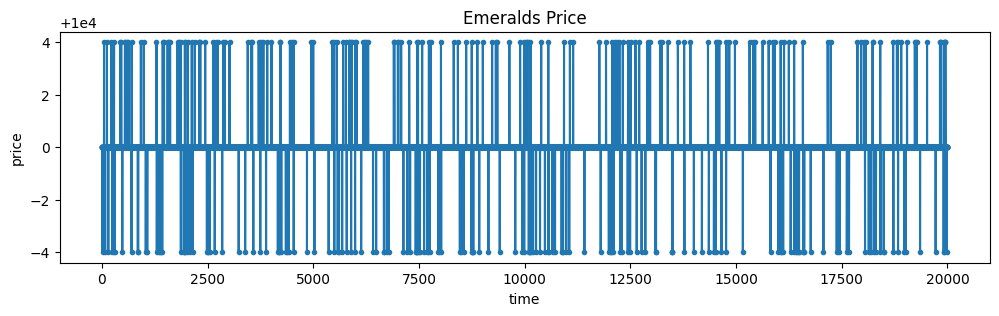

In [13]:
plt.figure(figsize=(12, 3))
plt.plot(price_emeralds['mid_price'], marker='.')
plt.title('Emeralds Price')
plt.xlabel('time')
plt.ylabel('price')
plt.show()

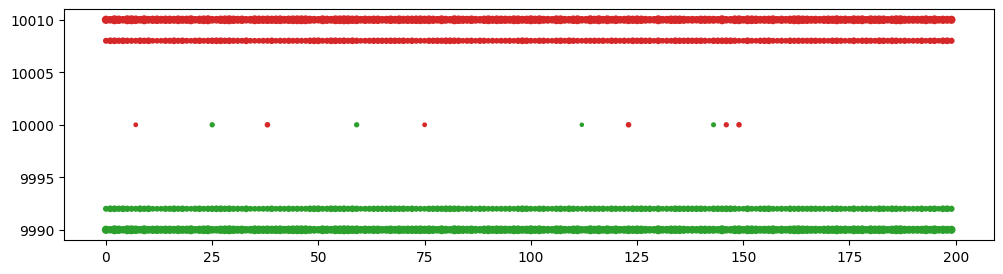

In [10]:
plt.figure(figsize=(12, 3))
plt.scatter(price_emeralds.iloc[:200]['timestamp']//100, price_emeralds.iloc[:200]['bid_price_1'], s=price_emeralds.iloc[:200]['bid_volume_1'], c='tab:green')
plt.scatter(price_emeralds.iloc[:200]['timestamp']//100, price_emeralds.iloc[:200]['bid_price_2'], s=price_emeralds.iloc[:200]['bid_volume_2'], c='tab:green')
plt.scatter(price_emeralds.iloc[:200]['timestamp']//100, price_emeralds.iloc[:200]['bid_price_3'], s=price_emeralds.iloc[:200]['bid_volume_3'], c='tab:green')
plt.scatter(price_emeralds.iloc[:200]['timestamp']//100, price_emeralds.iloc[:200]['ask_price_1'], s=price_emeralds.iloc[:200]['ask_volume_1'], c='tab:red')
plt.scatter(price_emeralds.iloc[:200]['timestamp']//100, price_emeralds.iloc[:200]['ask_price_2'], s=price_emeralds.iloc[:200]['ask_volume_2'], c='tab:red')
plt.scatter(price_emeralds.iloc[:200]['timestamp']//100, price_emeralds.iloc[:200]['ask_price_3'], s=price_emeralds.iloc[:200]['ask_volume_3'], c='tab:red')
plt.show()

# TOMATOES

In [4]:
price_tomatoes

,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price
1,0,TOMATOES,4993,7,4992,17,NaN,NaN,5007,7,5008,17,NaN,NaN,5000.0
2,100,TOMATOES,4998,5,4993,7,4992.0,16.0,5007,7,5008,16,NaN,NaN,5002.5
4,200,TOMATOES,4994,6,4993,20,NaN,NaN,5008,6,5009,20,NaN,NaN,5001.0
7,300,TOMATOES,4995,5,4993,21,NaN,NaN,5008,5,5009,21,NaN,NaN,5001.5
9,400,TOMATOES,4995,8,4993,20,NaN,NaN,5008,8,5009,20,NaN,NaN,5001.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19990,999500,TOMATOES,5000,7,4999,20,NaN,NaN,5014,7,5015,20,NaN,NaN,5007.0
19993,999600,TOMATOES,5000,7,4999,22,NaN,NaN,5014,7,5015,22,NaN,NaN,5007.0
19994,999700,TOMATOES,4999,10,4998,18,NaN,NaN,5013,10,5014,18,NaN,NaN,5006.0
19997,999800,TOMATOES,5000,7,4999,24,NaN,NaN,5014,7,5015,24,NaN,NaN,5007.0


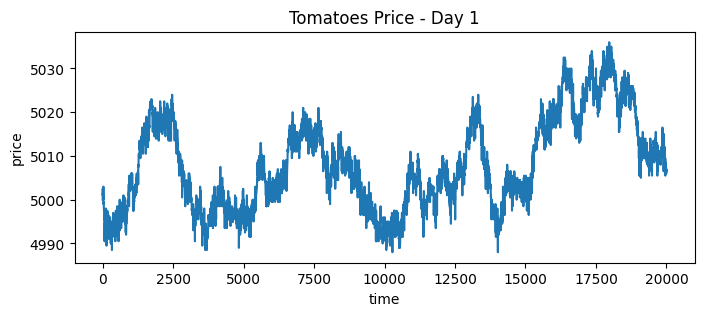

In [47]:
plt.figure(figsize=(8, 3))
plt.plot(price_tomatoes['mid_price'])
plt.title('Tomatoes Price - Day 1')
plt.xlabel('time')
plt.ylabel('price')
plt.show()

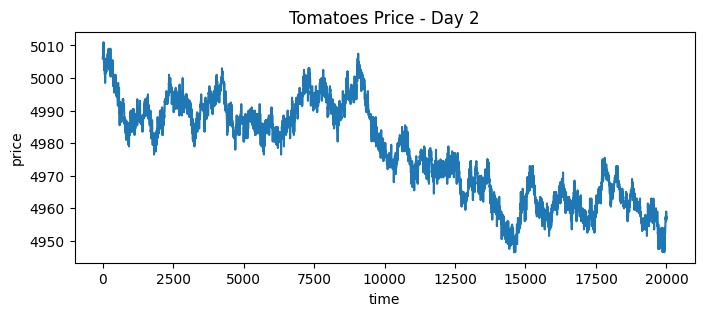

In [46]:
plt.figure(figsize=(8, 3))
plt.plot(price_tomatoes_test['mid_price'])
plt.title('Tomatoes Price - Day 2')
plt.xlabel('time')
plt.ylabel('price')
plt.show()

In [48]:
price_tomatoes = price_tomatoes.assign(filtered_mid=(price_tomatoes['bid_price_2'] + price_tomatoes['ask_price_2']) / 2)
price_tomatoes_test = price_tomatoes_test.assign(filtered_mid=(price_tomatoes_test['bid_price_2'] + price_tomatoes_test['ask_price_2']) / 2)

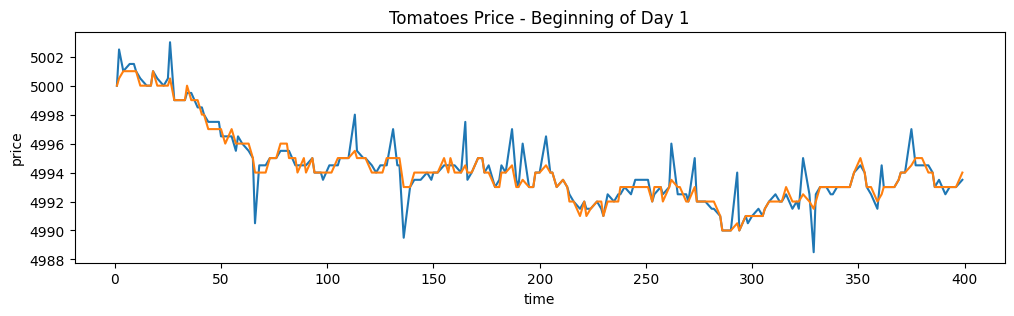

In [51]:
plt.figure(figsize=(12, 3))
plt.plot(price_tomatoes['mid_price'][:200])
plt.plot(price_tomatoes['filtered_mid'][:200])
plt.title('Tomatoes Price - Beginning of Day 1')
plt.xlabel('time')
plt.ylabel('price')
plt.show()

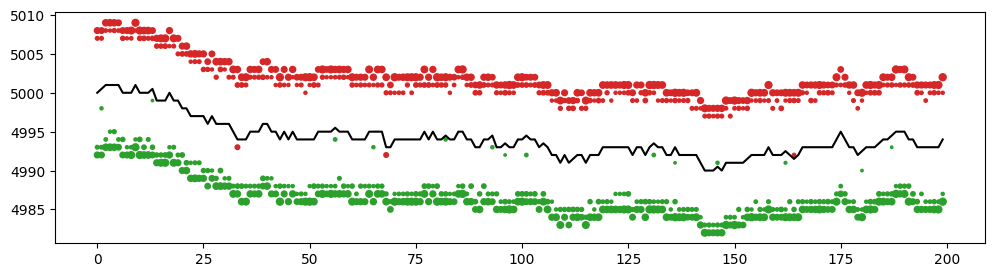

In [50]:
plt.figure(figsize=(12, 3))
plt.scatter(price_tomatoes.iloc[:200]['timestamp']//100, price_tomatoes.iloc[:200]['bid_price_1'], s=price_tomatoes.iloc[:200]['bid_volume_1'], c='tab:green')
plt.scatter(price_tomatoes.iloc[:200]['timestamp']//100, price_tomatoes.iloc[:200]['bid_price_2'], s=price_tomatoes.iloc[:200]['bid_volume_2'], c='tab:green')
plt.scatter(price_tomatoes.iloc[:200]['timestamp']//100, price_tomatoes.iloc[:200]['bid_price_3'], s=price_tomatoes.iloc[:200]['bid_volume_3'], c='tab:green')
plt.scatter(price_tomatoes.iloc[:200]['timestamp']//100, price_tomatoes.iloc[:200]['ask_price_1'], s=price_tomatoes.iloc[:200]['ask_volume_1'], c='tab:red')
plt.scatter(price_tomatoes.iloc[:200]['timestamp']//100, price_tomatoes.iloc[:200]['ask_price_2'], s=price_tomatoes.iloc[:200]['ask_volume_2'], c='tab:red')
plt.scatter(price_tomatoes.iloc[:200]['timestamp']//100, price_tomatoes.iloc[:200]['ask_price_3'], s=price_tomatoes.iloc[:200]['ask_volume_3'], c='tab:red')
plt.plot(price_tomatoes.iloc[:200]['timestamp']//100, price_tomatoes['filtered_mid'][:200], c='k')
plt.show()

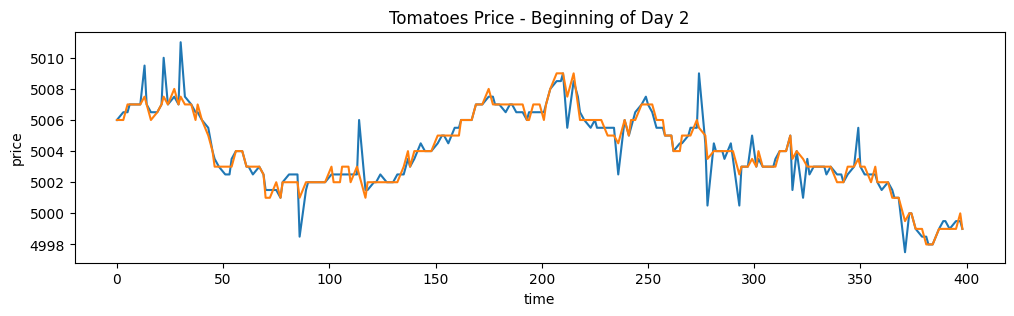

In [52]:
plt.figure(figsize=(12, 3))
plt.plot(price_tomatoes_test['mid_price'][:200])
plt.plot(price_tomatoes_test['filtered_mid'][:200])
plt.title('Tomatoes Price - Beginning of Day 2')
plt.xlabel('time')
plt.ylabel('price')
plt.show()

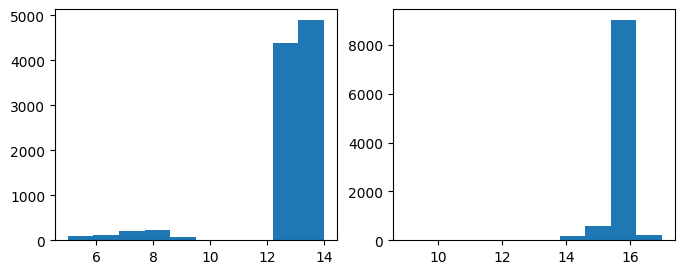

In [98]:
fig, ax = plt.subplots(1, 2, figsize=(8, 3))
ax[0].hist(price_tomatoes['ask_price_1'] - price_tomatoes['bid_price_1'])
ax[1].hist(price_tomatoes['ask_price_2'] - price_tomatoes['bid_price_2'])
plt.show()

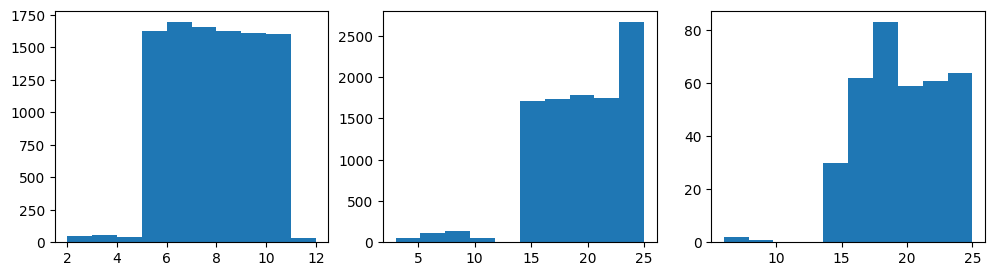

In [99]:
fig, ax = plt.subplots(1, 3, figsize=(12, 3))
ax[0].hist(price_tomatoes['bid_volume_1'])
ax[1].hist(price_tomatoes['bid_volume_2'])
ax[2].hist(price_tomatoes['bid_volume_3'])
plt.show()

# TOMATOES Forcasting

In [53]:
train_logr = np.log(price_tomatoes['filtered_mid']).diff().dropna()
test_logr = np.log(price_tomatoes_test['filtered_mid']).diff().dropna()

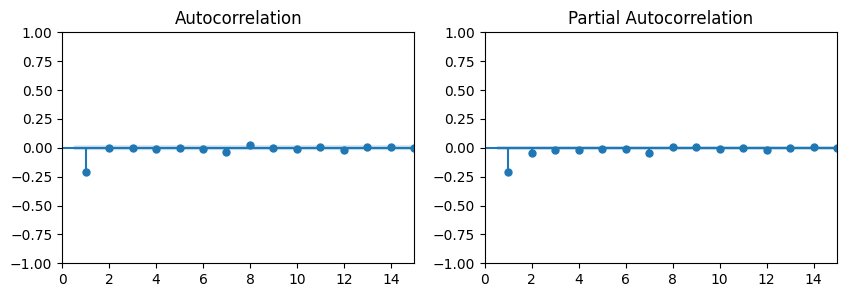

In [54]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3))
plot_acf(logr_tomatoes, ax=ax[0], zero=False)
plot_pacf(logr_tomatoes, ax=ax[1], zero=False)
ax[0].set_xlim([0, 15])
ax[1].set_xlim([0, 15])
plt.show()

In [57]:
# Perform Ljung-Box test for lags up to 10
result = acorr_ljungbox(train_logr, lags=[10], return_df=True)
print(result)

# Interpretation
if result['lb_pvalue'].values[0] > 0.05:
    print("Fail to reject null hypothesis: data may be white noise.")
else:
    print("Reject null hypothesis: data is not white noise.")

       lb_stat     lb_pvalue
10  461.694601  6.682467e-93
Reject null hypothesis: data is not white noise.


In [71]:
true = test_logr[1:].to_numpy()

In [72]:
# Naive
pred = test_logr[:-1].to_numpy()
err = true - pred
rmse = np.mean(err ** 2) ** 0.5
print(f'Naive RMSE: {rmse}')

Naive RMSE: 0.00020966653184623836


In [85]:
# AR(1)
coeffs = np.polyfit(train_logr[:-1], train_logr[1:], deg=1)
a, b = coeffs
print(f'Params: a = {round(a, 2)}, b = {round(b, 2)}')

pred = test_logr[:-1].to_numpy() * a
err = true - pred
rmse = np.mean(err ** 2) ** 0.5
print(f'AR(1) RMSE: {rmse}')

Params: a = -0.21, b = 0.0
AR(1) RMSE: 0.00013119439974993094
